# Section 2: Data processing


This notebook is used to produce a `python` [RISE](https://rise.readthedocs.io/en/latest/) slideshow to accompany the first section of the introduction to `python` content for practical component of _KYA211: Waves and Kinetic Theory_ at the University of Tasmania.

**Version**: 1.0  
**Created**: 06/03/2026 (AJM)  
**Updated**: 06/03/2026 (AJM)

## Import packages

To streamline operations in Python, packages can be imported to perform a host of various tasks. The packages used here are:
- [NumPy](https://numpy.org/) describes itself as 
> The fundamental package for scientific computing with Python

and it is not wrong. It is almost unfamthomable to do coding for scientific purposes without _NumPy_
- [Matplotlib](https://matplotlib.org/) states that is
> a comprehensive library for creating static, animated, and interactive visualizations in Python

and it really is what it claims to be, and will be fundamental to your `python` usage in maths and physics.

- [Pandas](https://pandas.pydata.org/) self-desribes as
> a fast, powerful, flexible and easy to use open source data analysis and manipulation tool

and is, at this stage, an optional package to aid with data analysis, but is often used in the first instance as a robust way to import and clean data.

To import a package (provided that the package has been installed for use) we can use an `import` statement, which (drumroll...) imports a package, that is, a bunch of code which is neatly packaged up for use into our code.

Here we begin by importing _numpy_, and then by importing _scipy_, but as scipy is a big, heavy module, most of which we do not need, we can import only the submodule that we need, namely the _integrate_ submodule. The code to do this is shown below

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Data processing

KYA211, Andy McCulloch

## Entrenching the path 

To get us back in the `python` zone, let us look in detail at arrays and loops:

```python
n = 0 # set the variable n = 0

while n < 10: # logic to check that n<10
    print(n) # print the value of n
    n += 1 # increase the value of n by 1

print(n)
```

Importantly, is the previous example, `n` is an integer. You can always check what is the `type` of an object using (unsurprisingly!) the `type()` function:

This is very different to the following:

```python
n = np.arange(10) # makes an array [0-9]

for element in n: # make a loop over all values in the array n
    print(element) # print the value of the element

print(n)
```

What kind of opbject is `n`?

`python` is _very_ powerful when you can do things with arrays, which includes when one has arrays of arrays (matrices)

**ASIDE**: suppose we wanted to compute the eigenvalues and eigenvectors of a matrix:

$$
\begin{pmatrix}
    2 & 3 & 1 \\
    9 & 4 & 3 \\
    -6 & 3 & 1
\end{pmatrix}
$$

one can use `np.linalg.eig([[2,3,1],[9,4,3],[-6,3,1]])`

So we are going to look in detail at how one gets arrays of data, and then does stuff with those arrays

## Array formation

Often, we will have data from an experiment, but sometimes we want to generate data. We have seen the function `np.arange(a,b)` which is used to make an array going from $a$ to $b$ in integer steps.

Often we want arrays that have a more complex strucutre, say with non-integer steps. A good place to start when wanting to do this kind of thing is to look at the documentation for the package one is using. For example, let us look at the `np.arange()` [docs](https://numpy.org/devdocs/reference/generated/numpy.arange.html)

When using _Jupyter_, the user-friendly web interface that we are currently using to code, one can access some so-called _magic_. An useful _magic_ operation in `?` which can get show you what _jupyter_ knows about a given function, for example:

```python
?np.arange
```

But as you might be getting a flavour for, there are many different ways to accomplish the same task. For example, other common ways to generate include

```python
np.linspace(0,10) # Specify a start, stop, number of points, has good enpoint control
np.zeros(10) # What it says on the tin; more useful than you might think
np.empty(10) # Also what it says on the tin; more useful than you might think
```

> So what should I use?

It doesn't matter. When one starts out coding, computation time is insignificant and efficiency is not the key, the output is the main goal. You will slowly learn when certain approaches are best placed to tackle a problem, but also creativity is a core component of coding. 

## List comprehension

Sometimes one needs to make non-trivial lists, for example if a list were required where points were not evenly spaced. A good example would be looking at Power Spectral Densities, where one wants to look from $\mathrm{Hz}$ to $\mathrm{GHz}$.

How might we do this?

The code snippet below in composed of a few key steps:

```python
n = range(10)

decades = []

for exponent in n:
    decades.append(10 ** exponent)
    
print(decades)
```

1. Initialise an empty list (decades)
2. Perform a loop over some other list (n)
3. Append the result from the calculation within loop to the initialised list
4. Loop over all elements in the other list (n)

The output is the list decades, which will now have the same length at the list n, but with fully configurable entries

This approach can be simplified using _list comprehension_, something which is fundamental to using `python`.

It essentially takes the previous snippet of code and then wraps to together as shorthand. So, to produce the same output, we can write:

``` python
decades = [10**n for n in range(-3, 5)]
```

Recall that lists do not behave in the way we typically want them to when doing analysis. For example, if I want to double each element, I cannot do

```python
decades * 2
```

How could I do it?

[0.002, 0.02, 0.2, 2, 20, 200, 2000, 20000]

We can also convert lists into arrays by using the `np.array()` function:

In [37]:
np.array(decades)

array([1.e-03, 1.e-02, 1.e-01, 1.e+00, 1.e+01, 1.e+02, 1.e+03, 1.e+04])

## Data generation

Sometimes we might like to _create_ data to verify a model. It should be clear that using programming, you can construct any model from the ground up using the fundamental building blocks, but for common tasks, it is likely that a highly-optimised routine already exists for the task.

For example we can generate samples from a normal distribution easily via `np.random.normal(μ, σ, N)`

We can also perform calculate the quantities of interest with ease:
- `np.mean()`
- `np.variance()`
- `np.std()`
- `np.average()` : can be used for weighted averages

np.float64(3.018843079102551)

**Into the weeds**: We can use the functions as shown above, but `objects` in python have functions built into them - called `methods`. This means that we can directly ask the `object` to tell us the property, for example:

```python
s = np.random.normal(10,3,1000)
s.mean()
```

np.float64(10.0002361113796)

It is important to be aware that `np.mean(sample)` and `sample.mean()` as you will see this kind of thing everywhere.

## Plotting data

Often we will be in the situation whereby we have both data, and some kind of theoretical model. We will look more closely at fitting in the next workshop, but for the moment, we want to plot an expected distribtuion along with a generated distribution.

Consider the normal distribution, which has the probability density
    
$$
\frac{1}{\sqrt{2\pi\sigma^2}}e^{-\frac{(x-\mu)^2}{2\sigma^2}}
$$

Let's make a plot of this distribution, and also generate a sample with the same mean and standard deviation.

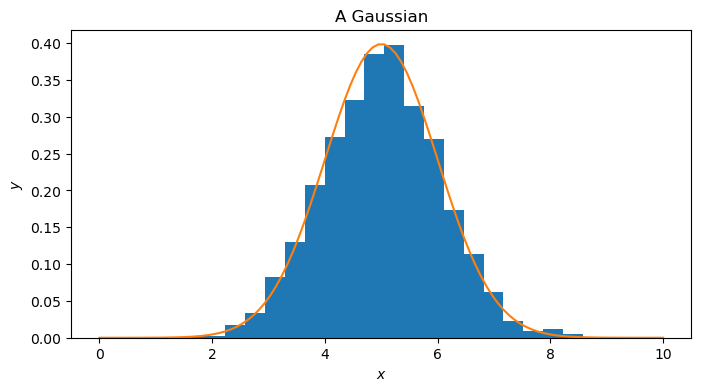

In [55]:
import numpy as np
import matplotlib.pyplot as plt

def gaussian(x, sigma, mu):
    scale = 1/(np.sqrt(2 * np.pi * sigma ** 2)) 
    exponent = - (x - mu) ** 2 / (2 * sigma ** 2)
    return scale * np.exp(exponent)

mu = 5
sigma = 1
number = 1000

sample = np.random.normal(mu, sigma, number)

xvals = np.linspace(0,10,100)
yvals = gaussian(xvals, sigma, mu)

fig = plt.figure(figsize=(8, 4))

plt.hist(sample, bins = 20, color = 'C0', density = True)
plt.plot(xvals, yvals, c='C1')

plt.title('A Gaussian')
plt.xlabel('$x$')
plt.ylabel('$y$')

plt.show()

## Plotting particulars

There are _many_ particularities to making `matplotlib` do what you want it to. Some of the main things to watch out for:

If you want things to appear on a different plot (not the same) you must call an new plot object:

In [ ]:
x = np.linspace(0, 2*np.pi, 100)

plt.figure()
plt.plot(x, np.sin(x))
plt.title("Sine")

plt.figure()
plt.plot(x, np.cos(x))
plt.title("Cosine")

plt.show()

Calling `plt.plt()` multiple times will result in plots with different colours. 

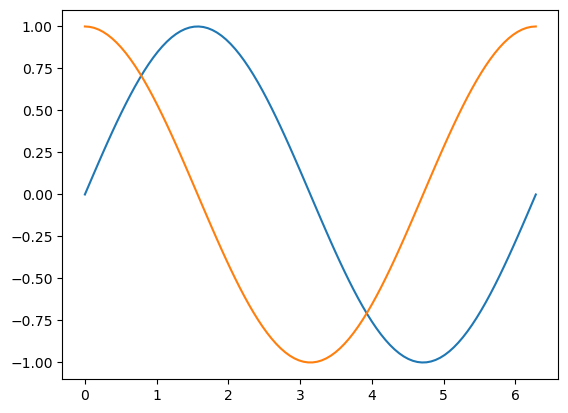

In [63]:
plt.figure()
plt.plot(x, np.sin(x))
plt.plot(x, np.cos(x))

plt.show()

You can control many aspects of a plot's appearance using optional inputs:
- `c` or `color` can be used to set the colour (!)
- `linestyle` can set the style of the line (!)
- `linewidth` sets the width of the line (!)
- `alpha` adjusts to opacity

It is important to spend time making your plots readible.

## Data manipulation

Data manipulation is one of the main and most complex tasks of any project, so it is important to know how to deftly handle data.

We have been looking at arrays, and basic operations using them. Now we shall look at manipulating them. 

In [4]:
%%capture

N = 1000
omega = 2 * np.pi * 1e3
t = np.linspace(-1e6, 1e6, N)
noise = np.random.normal(0,1,N)

V0 = 10
Vn = 1
V = V0 * np.sin(omega * t) + Vn * noise

failure = np.random.randint(0,N, np.random.randint(0,50))
for i in failure:
    V[i] = -101

Sometimes our data has artifacts, for example, a sensor failing:    

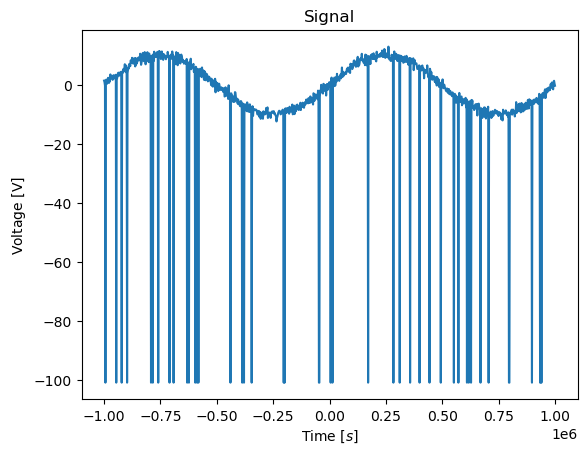

In [5]:
plt.figure()
plt.plot(t, V)
plt.title("Signal")
plt.xlabel('Time [$s$]')
plt.ylabel('Voltage [$\mathrm{V}$]')
plt.show()

Arrays can be used to find:
- `V > 8`: values in the array that are greater than 8
- `V < 10`: values in the array that are less than 10
- `(V < 10) & (8 < V)`: values that are both greater than 8 and less than 10
- `np.exp(-V ** 2) < 1e-2`: something much more non-trivial

Importantly, the result of these operations gives an array of `True` and `False` values. This may seem strange at first, but it is actually extremely powerful. In the case of our signal, there are some big negative values:

In [103]:
V < -20

array([-101., -101., -101., -101., -101., -101., -101., -101., -101.,
       -101., -101.])

If we use our array of `True` and `False` values, we can use this as an index for our array, and see what the values are at the "bad" points:

In [104]:
V[V < -20]

array([-101., -101., -101., -101., -101., -101., -101., -101., -101.,
       -101., -101.])

We can also select only the values that we know not to incorrect

In [107]:
V[V > -20]

array([-1.02488737e+00, -1.74289455e+00, -7.91371474e-03, -3.18768490e-01,
       -5.22316180e-01,  1.10080521e+00,  1.94099481e+00, -2.55327129e-01,
        2.25432570e-01,  3.16467435e+00, -3.24900588e-01,  5.25445079e-01,
       -3.29485240e-01,  3.03964471e+00,  3.26536121e+00,  3.14921095e-01,
        1.73095165e+00,  1.97548585e+00,  6.49164973e-01,  3.06677949e+00,
        3.76805912e+00,  4.38884730e+00,  2.11886298e+00,  1.88138922e+00,
        4.23978855e+00,  2.78442787e+00,  2.80303848e+00,  2.96848866e+00,
        4.68592812e+00,  4.11452974e+00,  3.95927587e+00,  4.64329225e+00,
        2.04959637e+00,  5.32337164e+00,  3.08032205e+00,  3.22098489e+00,
        3.66704778e+00,  3.63388277e+00,  4.38073173e+00,  5.65136000e+00,
        3.35513112e+00,  4.45747965e+00,  4.72021529e+00,  5.43029668e+00,
        5.26236639e+00,  3.98748649e+00,  6.33044770e+00,  5.70491190e+00,
        8.16509546e+00,  5.16991986e+00,  6.53360319e+00,  6.56589895e+00,
        6.81623138e+00,  

Let's plot this

ValueError: x and y must have same first dimension, but have shapes (1000,) and (956,)

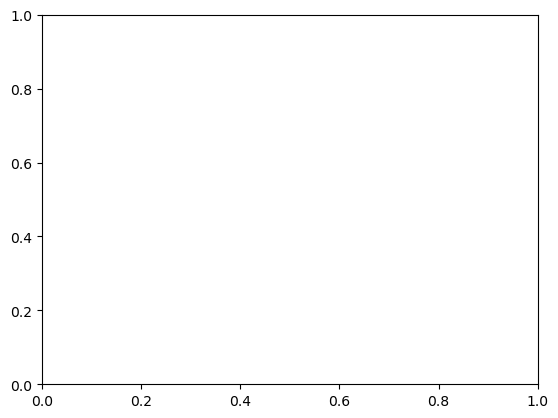

In [6]:
plt.figure()
plt.plot(t, V[V > -20])
plt.title("Signal")
plt.xlabel('Time [$s$]')
plt.ylabel('Voltage [$\mathrm{V}$]')
plt.show()

What went wrong?

We filtered the signal to remove the "bad" points, but we did not filter the associated time values.

Fortunately our truth table - the array returned from `V < -20` - will also select the time values we want!

In [20]:
mask = V < -20
mask = ~mask
V_wanted = V[mask]
t_wanted = t[mask]

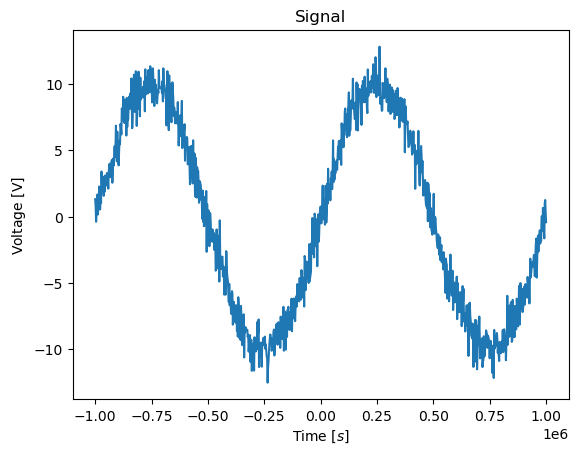

In [21]:
plt.figure()
plt.plot(t_wanted, V_wanted)
plt.title("Signal")
plt.xlabel('Time [$s$]')
plt.ylabel('Voltage [$\mathrm{V}$]')
plt.show()

In [17]:
V[mask]

array([ 1.32445065e+00,  7.73412268e-01, -3.74506483e-01,  7.23575445e-01,
        1.68050563e+00,  1.72850436e-01,  7.47335555e-01,  1.31915714e+00,
        2.27418487e+00,  5.72435834e-01,  5.48942394e-01,  1.44113304e+00,
        1.04561797e+00,  3.41152776e+00,  2.24516805e+00,  2.44928587e+00,
        2.69595150e+00,  2.14506089e+00,  1.57481103e+00,  3.03604403e+00,
        1.88309228e+00,  3.10762507e+00,  2.50611807e+00,  2.91481313e+00,
        2.35274087e+00,  3.29596330e+00,  2.59274847e+00,  2.11786599e+00,
        3.30060503e+00,  3.92414733e+00,  4.00405253e+00,  2.98703189e+00,
        3.19966731e+00,  3.17122793e+00,  4.13888688e+00,  4.28609901e+00,
        2.56547327e+00,  4.39240408e+00,  3.85271542e+00,  4.67767568e+00,
        5.31230849e+00,  4.50750157e+00,  5.27330922e+00,  6.86811062e+00,
        4.69392559e+00,  4.17560968e+00,  6.41527104e+00,  4.60095270e+00,
        3.87089665e+00,  4.99058451e+00,  5.74680219e+00,  5.47280668e+00,
        6.99274141e+00,  

## Pandas in the house

No discusision of data manipulation would be complete without `pandas`


<div>
<center>
    <img src="02/pandas.jpg" width="600"/> 
</center>
</div>

`pandas` is the primary library used for data science.

The name is derived from "**Pan**el **da**ta"

It is immensely powerful, but does have a learning curve. Fortunately, it is built upon `numpy`, so one can always revert to arrays if `pandas` becomes a bit difficult to wrangle.

The most likely use case is for the importation of data:

```python
import pandas as pd

data = pd.read_csv('file.csv')
```

which is easier to use, more configurable, and produces an object much closer to a data spreadsheet

In [63]:
# This is code to generate some example data to export to a .csv to later import as a .csv to demonstrate pd.read_csv()
# Let's make a noisy circle!

f = 3e4
A = 1
A_noise = 0.2
N = 1e4
N = int(N)

t = np.linspace(0, 1e-3, N)
x, y = A * np.cos(2*np.pi*f*t) + A_noise * np.random.normal(0,1,N), np.sin(2*np.pi*f*t) + A_noise * np.random.normal(0,1,N)

d = {'x': x, 'y': y}
df = pd.DataFrame(d, index = t)
df.to_csv('02/exampledata.csv')

In [ ]:
# the exaple file is '02/exampledata.csv'

0       1.220731
1       0.948509
2       0.885078
3       0.858455
4       1.209710
          ...   
9995    0.736892
9996    0.905324
9997    0.646723
9998    0.803163
9999    0.823101
Name: x, Length: 10000, dtype: float64

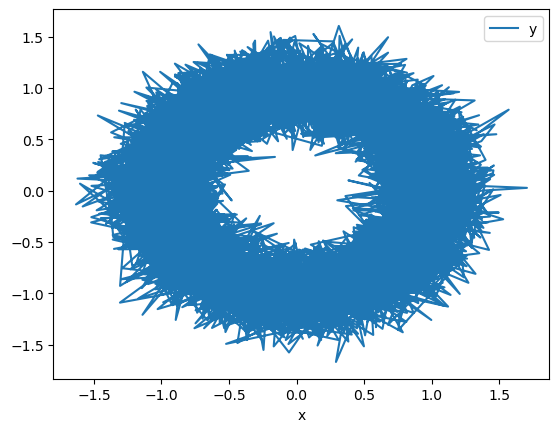

In [70]:
data = pd.read_csv('02/exampledata.csv')

data.plot('x', 'y')

x = data['x']
x

## The final word

We shall now try to perform some specific tasks with the techniques covered here. As a reminder:

**Internet searches/forums are fantastic ways to help you learn coding**